# Импорт бибилотек и константы

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import umap
import lightgbm as lgb
import matplotlib.pyplot as plt
import hdbscan
from scipy.interpolate import griddata
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, r2_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader, TensorDataset


c:\Users\qa1ro\OneDrive\Рабочий стол\diploma\diploma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_STATE = 21

# init

In [3]:
df = pd.read_feather("../datasets/united.feather")

In [4]:
df

,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed
0,2025-10-07 22:18:14.495,104.892,12781,13144,25512,0.02020
1,2025-10-07 22:18:19.239,101.430,18971,18936,25512,0.03636
2,2025-10-07 22:18:24.208,101.430,20153,18184,25512,0.03030
3,2025-10-07 22:18:29.385,102.714,20162,17445,25512,0.03030
4,2025-10-07 22:19:22.224,103.110,18591,19741,25512,0.02424
...,...,...,...,...,...,...
415044,2025-10-07 22:14:55.384,104.598,10071,13434,25512,0.03636
415045,2025-10-07 22:14:59.667,105.978,12308,12992,25512,0.03636
415046,2025-10-07 22:15:05.094,105.978,12363,15220,25512,0.01515
415047,2025-10-07 22:15:10.387,102.420,13499,14416,25512,0.01212


In [5]:
cols_for_clustering = ['rotation', 'pressure_rotation', 'pressure_axis', 'speed']
X = df[cols_for_clustering]
X.head()
k_range = range(3, 10)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Проверка методов кластеризации

## funcs

In [7]:
def bench_kmeans(inertias, silhouettes, features):
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(features)
        sil = silhouette_score(features, labels, sample_size=20_000, random_state=RANDOM_STATE)
        silhouettes.append(sil)
        inertias.append(km.inertia_)
        print(f"n_clusters: {k}, silhouette: {sil:.4f}, inertia: {km.inertia_:.4f}")

def bench_gmm(silhouettes, features):
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
        labels = gmm.fit_predict(features)
        sil = silhouette_score(features, labels, sample_size=20_000, random_state=RANDOM_STATE)
        silhouettes.append(sil)
        print(f"n_clusters: {k}, silhouette: {sil:.4f}")

def bench_hdbscan(results, features, min_sizes):
    for ms in min_sizes:
        clf = hdbscan.HDBSCAN(min_cluster_size=ms, core_dist_n_jobs=-1)
        labels = clf.fit_predict(features)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters > 1:
            sil = silhouette_score(features, labels, sample_size=20_000, random_state=RANDOM_STATE)
        else:
            sil = float("nan")
        results.append({"min_cluster_size": ms, "n_clusters": n_clusters, "n_noise": n_noise, "silhouette": sil})
        print(f"min_cluster_size: {ms}, n_clusters: {n_clusters}, n_noise: {n_noise}, silhouette: {sil:.4f}")


## KMeans на сырых фичах

In [8]:
inertias, silhouettes = [], []

In [9]:
bench_kmeans(inertias, silhouettes, X)

n_clusters: 3, silhouette: 0.4964, inertia: 2708574243791.7876
n_clusters: 4, silhouette: 0.4275, inertia: 1997819135575.8308
n_clusters: 5, silhouette: 0.3803, inertia: 1609682255390.0444
n_clusters: 6, silhouette: 0.3622, inertia: 1379851978653.7385
n_clusters: 7, silhouette: 0.3510, inertia: 1230304259299.1804
n_clusters: 8, silhouette: 0.3512, inertia: 1039000278079.0436
n_clusters: 9, silhouette: 0.3277, inertia: 957387021542.5197


## Kmeans на сырых фичах + standard scaler

In [10]:
inertias_scaled, silhouettes_scaled = [], []
bench_kmeans(inertias_scaled, silhouettes_scaled, X_scaled)

n_clusters: 3, silhouette: 0.2729, inertia: 893177.2678
n_clusters: 4, silhouette: 0.3209, inertia: 693559.4053
n_clusters: 5, silhouette: 0.2922, inertia: 608289.2686
n_clusters: 6, silhouette: 0.2970, inertia: 523670.1036
n_clusters: 7, silhouette: 0.2928, inertia: 463254.6501
n_clusters: 8, silhouette: 0.2886, inertia: 433742.8216
n_clusters: 9, silhouette: 0.2915, inertia: 400898.9307


## KMeans на пониженной размерности

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [12]:
inertias_dim_red, silhouettes_dim_red = [], []
bench_kmeans(inertias_dim_red, silhouettes_dim_red, X_pca)

n_clusters: 3, silhouette: 0.4960, inertia: 2708626400227.5352
n_clusters: 4, silhouette: 0.4269, inertia: 1997968243787.7322
n_clusters: 5, silhouette: 0.3807, inertia: 1609607723891.9294
n_clusters: 6, silhouette: 0.3650, inertia: 1380881635254.9385
n_clusters: 7, silhouette: 0.3696, inertia: 1179497087636.6409
n_clusters: 8, silhouette: 0.3531, inertia: 1106699464728.1245
n_clusters: 9, silhouette: 0.3384, inertia: 971123578284.8842


## GMM на сырых фичах

In [13]:
silhouettes_gmm = []
bench_gmm(silhouettes_gmm, X)

n_clusters: 3, silhouette: 0.1554
n_clusters: 4, silhouette: 0.1793
n_clusters: 5, silhouette: 0.0782


KeyboardInterrupt: 

## GMM на сырых фичах + standardscaler

In [ ]:
silhouettes_gmm = []
bench_gmm(silhouettes_gmm, X_scaled)

n_clusters: 3, silhouette: 0.3056
n_clusters: 4, silhouette: 0.3062
n_clusters: 5, silhouette: 0.2242
n_clusters: 6, silhouette: 0.1559
n_clusters: 7, silhouette: 0.1306
n_clusters: 8, silhouette: 0.1531
n_clusters: 9, silhouette: 0.1448


## GMM на пониженной размерности

In [ ]:
silhouettes_gmm_dim_red = []
bench_gmm(silhouettes_gmm_dim_red, X_pca)

n_clusters: 3, silhouette: 0.4845
n_clusters: 4, silhouette: 0.4197
n_clusters: 5, silhouette: 0.3710
n_clusters: 6, silhouette: 0.3315
n_clusters: 7, silhouette: 0.3479
n_clusters: 8, silhouette: 0.3416
n_clusters: 9, silhouette: 0.3360


## HDBSCAN на сырых фичах (подвыборка)

In [51]:
HDBSCAN_SUBSAMPLE = 50_000
HDBSCAN_MIN_SIZES = [50, 60, 70, 80, 90, 100]

rng = np.random.default_rng(RANDOM_STATE)
sub_idx = rng.choice(len(X), size=HDBSCAN_SUBSAMPLE, replace=False)
X_sub = X_scaled[sub_idx]

hdbscan_results = []
bench_hdbscan(hdbscan_results, X_sub, HDBSCAN_MIN_SIZES)

hdbscan_df = pd.DataFrame(hdbscan_results)
hdbscan_df

min_cluster_size: 50, n_clusters: 13, n_noise: 20114, silhouette: -0.1962
min_cluster_size: 60, n_clusters: 4, n_noise: 6930, silhouette: 0.2542
min_cluster_size: 70, n_clusters: 2, n_noise: 292, silhouette: 0.3761
min_cluster_size: 80, n_clusters: 2, n_noise: 312, silhouette: 0.3757
min_cluster_size: 90, n_clusters: 2, n_noise: 362, silhouette: 0.3738
min_cluster_size: 100, n_clusters: 2, n_noise: 409, silhouette: 0.3725


,min_cluster_size,n_clusters,n_noise,silhouette
0,50,13,20114,-0.196219
1,60,4,6930,0.254230
2,70,2,292,0.376118
3,80,2,312,0.375695
4,90,2,362,0.373772
5,100,2,409,0.372504


# Проверка регрессии

In [7]:
REGRESSION_FEATURES = ['pressure_axis', 'pressure_rotation']
N_SPLITS = 5
gkf    = GroupKFold(n_splits=N_SPLITS)
groups = df['well_id'].values

def bench_lgbm(cluster_labels):
    feat_df = df[REGRESSION_FEATURES].assign(cluster=cluster_labels)
    r2s = {}
    for target in ['speed', 'rotation']:
        y = df[target].values
        fold_r2s = []
        for train_idx, test_idx in gkf.split(feat_df, y, groups):
            model = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
            model.fit(feat_df.iloc[train_idx], y[train_idx])
            fold_r2s.append(r2_score(y[test_idx], model.predict(feat_df.iloc[test_idx])))
        r2s[target] = np.mean(fold_r2s)
    return r2s

## KMeans / GMM + LightGBM

In [8]:
LGBM_SUBSAMPLE = 50_000
_rng = np.random.default_rng(RANDOM_STATE)
_sub_idx = _rng.choice(len(X_scaled), size=min(LGBM_SUBSAMPLE, len(X_scaled)), replace=False)
X_sub_scaled = X_scaled[_sub_idx]

rows = []
cluster_labels_dict = {}  # (method, param) -> full-dataset labels

# --- KMeans ---
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X_scaled)
    cluster_labels_dict[("KMeans", k)] = labels
    r2s = bench_lgbm(labels)
    rows.append({"method": "KMeans", "n_clusters": k, "r2_speed": r2s["speed"], "r2_rotation": r2s["rotation"]})

# --- GMM ---
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    labels = gmm.fit_predict(X_scaled)
    cluster_labels_dict[("GMM", k)] = labels
    r2s = bench_lgbm(labels)
    rows.append({"method": "GMM", "n_clusters": k, "r2_speed": r2s["speed"], "r2_rotation": r2s["rotation"]})

## + Agg + Dbscan

In [ ]:
# --- AgglomerativeClustering (fit on subsample, propagate via KNN) ---
_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k)
    sub_labels = agg.fit_predict(X_sub_scaled)
    _knn.fit(X_sub_scaled, sub_labels)
    labels = _knn.predict(X_scaled)
    cluster_labels_dict[("Agglomerative", k)] = labels
    r2s = bench_lgbm(labels)
    rows.append({"method": "Agglomerative", "n_clusters": k, "r2_speed": r2s["speed"], "r2_rotation": r2s["rotation"]})
    print(f"Agglomerative k={k} done")

# --- HDBSCAN (fit on subsample, approximate_predict for full dataset) ---
HDBSCAN_MIN_SIZES_LGBM = [100, 200, 500]
for ms in HDBSCAN_MIN_SIZES_LGBM:
    clf = hdbscan.HDBSCAN(min_cluster_size=ms, prediction_data=True, core_dist_n_jobs=-1)
    clf.fit(X_sub_scaled)
    labels_full, _ = hdbscan.approximate_predict(clf, X_scaled)
    n_clusters = len(set(labels_full)) - (1 if -1 in labels_full else 0)
    if n_clusters < 2:
        print(f"HDBSCAN min_cluster_size={ms}: {n_clusters} cluster(s), skipping")
        continue
    cluster_labels_dict[("HDBSCAN", ms)] = labels_full
    r2s = bench_lgbm(labels_full)
    rows.append({"method": "HDBSCAN", "n_clusters": n_clusters, "min_cluster_size": ms,
                 "r2_speed": r2s["speed"], "r2_rotation": r2s["rotation"]})
    print(f"HDBSCAN min_cluster_size={ms}, n_clusters={n_clusters} done")


Agglomerative k=3 done
Agglomerative k=4 done
Agglomerative k=5 done
Agglomerative k=6 done
Agglomerative k=7 done
Agglomerative k=8 done
Agglomerative k=9 done
HDBSCAN min_cluster_size=100, n_clusters=2 done
HDBSCAN min_cluster_size=200, n_clusters=2 done
HDBSCAN min_cluster_size=500, n_clusters=2 done


,method,n_clusters,r2_speed,r2_rotation,min_cluster_size
0,KMeans,3,0.550428,0.156690,NaN
1,KMeans,4,0.543874,0.680656,NaN
2,KMeans,5,0.563750,0.698094,NaN
3,KMeans,6,0.576746,0.820516,NaN
4,KMeans,7,0.662630,0.813736,NaN
5,KMeans,8,0.666031,0.855215,NaN
6,KMeans,9,0.667099,0.911291,NaN
7,GMM,3,0.176962,0.482147,NaN
8,GMM,4,0.258954,0.885719,NaN
9,GMM,5,0.261989,0.885133,NaN


In [9]:

results_df = pd.DataFrame(rows)
results_df


,method,n_clusters,r2_speed,r2_rotation
0,KMeans,3,0.550428,0.156690
1,KMeans,4,0.543874,0.680656
2,KMeans,5,0.563750,0.698094
3,KMeans,6,0.576746,0.820516
4,KMeans,7,0.662630,0.813736
5,KMeans,8,0.666031,0.855215
6,KMeans,9,0.667099,0.911291
7,GMM,3,0.176962,0.482147
8,GMM,4,0.258954,0.885719
9,GMM,5,0.261989,0.885133


## KMeans / GMM + MLP

In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0+cu130
CUDA available: True
CUDA version: 13.0


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 50
BATCH_SIZE = 8192
LR = 1e-3
print(f"device: {DEVICE}")


class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

    def reset_parameters(self):
        for m in self.net:
            if hasattr(m, 'reset_parameters'):
                m.reset_parameters()

device: cuda
3
4
5
6
7
8
9
3
4
5
6
7
8
9


,method,n_clusters,r2_speed,r2_rotation
0,KMeans-MLP,3,0.432184,0.141397
1,KMeans-MLP,4,0.330955,0.671235
2,KMeans-MLP,5,0.370876,0.689359
3,KMeans-MLP,6,0.487115,0.802781
4,KMeans-MLP,7,0.500560,0.805542
5,KMeans-MLP,8,0.508997,0.736707
6,KMeans-MLP,9,0.287490,0.894911
7,GMM-MLP,3,0.153451,0.474317
8,GMM-MLP,4,0.180378,0.885013
9,GMM-MLP,5,0.211993,0.881149


In [ ]:
_model = MLP().to(DEVICE)
_opt   = torch.optim.Adam(_model.parameters(), lr=LR)
_loss_fn = nn.MSELoss()

def train_predict(X_tr, y_tr, X_te):
    Xtr = torch.from_numpy(X_tr).to(DEVICE)
    ytr = torch.from_numpy(y_tr).to(DEVICE)
    Xte = torch.from_numpy(X_te).to(DEVICE)

    _model.reset_parameters()
    for pg in _opt.param_groups:
        pg['lr'] = LR
    _opt.state.clear()

    n = Xtr.size(0)
    _model.train()
    for _ in range(EPOCHS):
        idx = torch.randperm(n, device=DEVICE)
        for i in range(0, n, BATCH_SIZE):
            sel = idx[i:i + BATCH_SIZE]
            xb, yb = Xtr[sel], ytr[sel]
            _opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                loss = _loss_fn(_model(xb), yb)
            loss.backward()
            _opt.step()

    _model.eval()
    with torch.no_grad(), torch.amp.autocast('cuda'):
        return _model(Xte).float().cpu().numpy()


def bench_mlp(cluster_labels):
    base = df[REGRESSION_FEATURES].assign(cluster=cluster_labels).values.astype(np.float32)
    r2s  = {}
    for target in ['speed', 'rotation']:
        y = df[target].values.astype(np.float32)
        fold_r2s = []
        for train_idx, test_idx in gkf.split(base, y, groups):
            sc   = StandardScaler()
            X_tr = sc.fit_transform(base[train_idx])
            X_te = sc.transform(base[test_idx])
            preds = train_predict(X_tr, y[train_idx], X_te)
            fold_r2s.append(r2_score(y[test_idx], preds))
        r2s[target] = np.mean(fold_r2s)
    return r2s


mlp_rows = []

for k in k_range:
    print(k)
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    r2s = bench_mlp(km.fit_predict(X_scaled))
    mlp_rows.append({'method': 'KMeans-MLP', 'n_clusters': k, 'r2_speed': r2s['speed'], 'r2_rotation': r2s['rotation']})

for k in k_range:
    print(k)
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    r2s = bench_mlp(gmm.fit_predict(X_scaled))
    mlp_rows.append({'method': 'GMM-MLP', 'n_clusters': k, 'r2_speed': r2s['speed'], 'r2_rotation': r2s['rotation']})

In [ ]:
mlp_df = pd.DataFrame(mlp_rows)
mlp_df

In [23]:
df_result = pd.concat([mlp_df, results_df], ignore_index=True)
df_result.sort_values(by="r2_speed", ascending=False)

,method,n_clusters,r2_speed,r2_rotation
20,KMeans,9,0.667099,0.911291
19,KMeans,8,0.666031,0.855215
18,KMeans,7,0.662630,0.813736
17,KMeans,6,0.576746,0.820516
16,KMeans,5,0.563750,0.698094
14,KMeans,3,0.550428,0.156690
15,KMeans,4,0.543874,0.680656
5,KMeans-MLP,8,0.508997,0.736707
4,KMeans-MLP,7,0.500560,0.805542
3,KMeans-MLP,6,0.487115,0.802781


# Visualization

## распределение наблюдений по кластерам

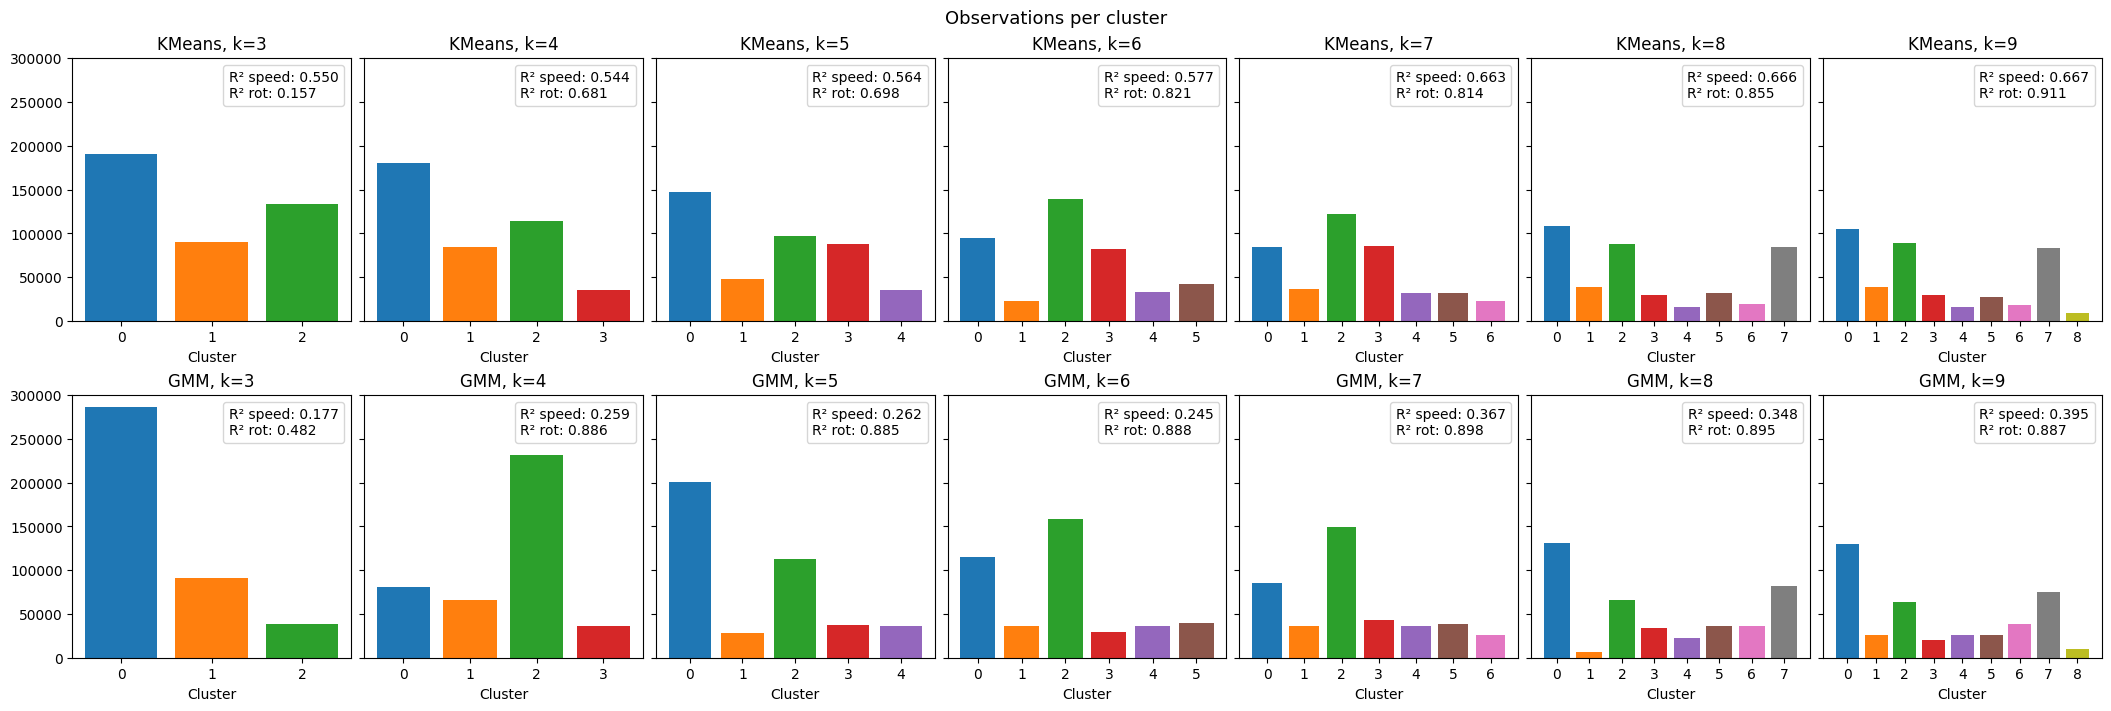

In [20]:
# build (method, param) -> r2 lookup
_r2_lookup = {}
for _, row in results_df.iterrows():
    m = row["method"]
    param_key = int(row["min_cluster_size"]) if m == "HDBSCAN" else int(row["n_clusters"])
    _r2_lookup[(m, param_key)] = (row["r2_speed"], row["r2_rotation"])

methods_viz = ["KMeans", "GMM"]
k_list = list(k_range)
n_k = len(k_list)
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, n_k, figsize=(n_k * 3, 7), sharey=True, constrained_layout=True)

for row_idx, method in enumerate(methods_viz):
    for col_idx, k in enumerate(k_list):
        ax = axes[row_idx, col_idx]
        labels = cluster_labels_dict[(method, k)]
        counts = pd.Series(labels).value_counts().sort_index()
        ax.bar(range(len(counts)), counts.values,
               color=[colors[i % 10] for i in counts.index],
               tick_label=counts.index.tolist())
        ax.set_title(f"{method}, k={k}")
        ax.set_xlabel("Cluster")
        r2_spd, r2_rot = _r2_lookup.get((method, k), (float("nan"), float("nan")))
        ax.legend([f"R² speed: {r2_spd:.3f}\nR² rot: {r2_rot:.3f}"], loc="upper right", fontsize=10, framealpha=0.8, handlelength=0, handletextpad=0)
plt.suptitle("Observations per cluster", fontsize=13)
plt.show()


## hypothesis

Per-cluster models — overall OOF R²:
  speed: 0.5483
  rotation: 0.1552


,target,rotation,speed
cluster,n_obs,,
0,190394,0.073600,0.091200
1,90592,0.144800,0.092400
2,134063,0.030000,0.115000


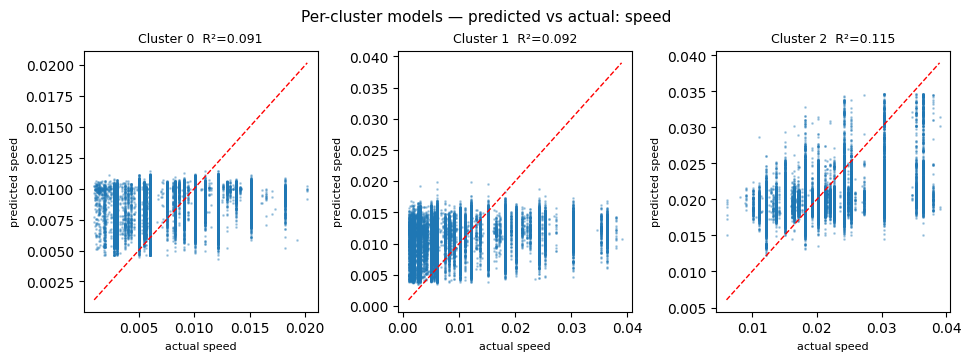

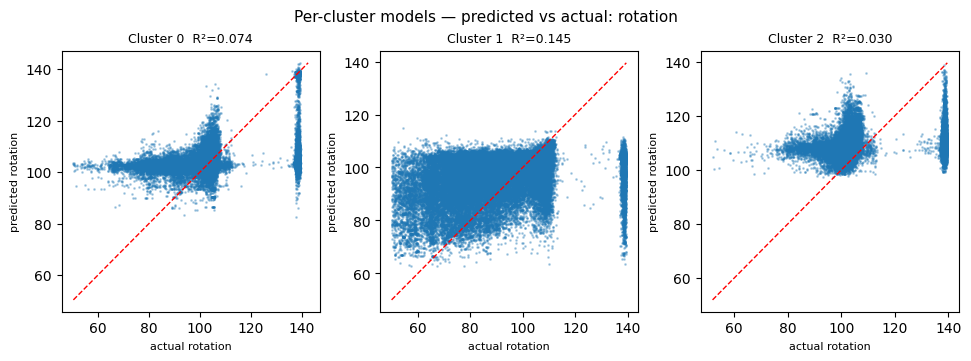

In [33]:
HYP_K = 3
HYP_FEATURES = ["pressure_axis", "pressure_rotation"]

km5 = KMeans(n_clusters=HYP_K, random_state=RANDOM_STATE, n_init='auto')
labels5 = km5.fit_predict(X_scaled)

# ── train one LightGBM per cluster, OOF predictions ──────────────────────────
oof = {t: np.full(len(df), np.nan) for t in ["speed", "rotation"]}

for cid in range(HYP_K):
    mask  = labels5 == cid
    feat  = df.loc[mask, HYP_FEATURES]
    grp   = df.loc[mask, "well_id"].values
    n_sp  = min(N_SPLITS, len(np.unique(grp)))

    for target in ["speed", "rotation"]:
        y = df.loc[mask, target].values
        fold_preds = np.full(len(y), np.nan)
        for tr, te in GroupKFold(n_splits=n_sp).split(feat, y, grp):
            m = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
            m.fit(feat.iloc[tr], y[tr])
            fold_preds[te] = m.predict(feat.iloc[te])
        oof[target][mask] = fold_preds

# ── overall R² across all clusters ───────────────────────────────────────────
print("Per-cluster models — overall OOF R²:")
for target in ["speed", "rotation"]:
    valid = ~np.isnan(oof[target])
    print(f"  {target}: {r2_score(df[target].values[valid], oof[target][valid]):.4f}")

# ── per-cluster R² table ──────────────────────────────────────────────────────
rows = []
for cid in range(HYP_K):
    mask = labels5 == cid
    for target in ["speed", "rotation"]:
        preds = oof[target][mask]
        y_true = df.loc[mask, target].values
        valid  = ~np.isnan(preds)
        rows.append({"cluster": cid, "n_obs": int(mask.sum()),
                     "target": target, "r2": r2_score(y_true[valid], preds[valid])})

r2_table = (pd.DataFrame(rows)
            .pivot_table(index=["cluster", "n_obs"], columns="target", values="r2")
            .round(4))
display(r2_table.style.background_gradient(cmap="RdYlGn"))

# ── predicted vs actual per cluster ──────────────────────────────────────────
for target in ["speed", "rotation"]:
    fig, axes = plt.subplots(1, HYP_K, figsize=(HYP_K * 3.2, 3.5), constrained_layout=True)
    for cid, ax in enumerate(axes):
        mask   = labels5 == cid
        y_true = df.loc[mask, target].values
        preds  = oof[target][mask]
        valid  = ~np.isnan(preds)
        r2 = r2_score(y_true[valid], preds[valid])
        ax.scatter(y_true[valid], preds[valid], s=1, alpha=0.3)
        lims = [min(y_true[valid].min(), preds[valid].min()),
                max(y_true[valid].max(), preds[valid].max())]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_title(f"Cluster {cid}  R²={r2:.3f}", fontsize=9)
        ax.set_xlabel(f"actual {target}", fontsize=8)
        ax.set_ylabel(f"predicted {target}", fontsize=8)
    fig.suptitle(f"Per-cluster models — predicted vs actual: {target}", fontsize=11)
    plt.show()


## 3D scatter — clusters

## t-sne

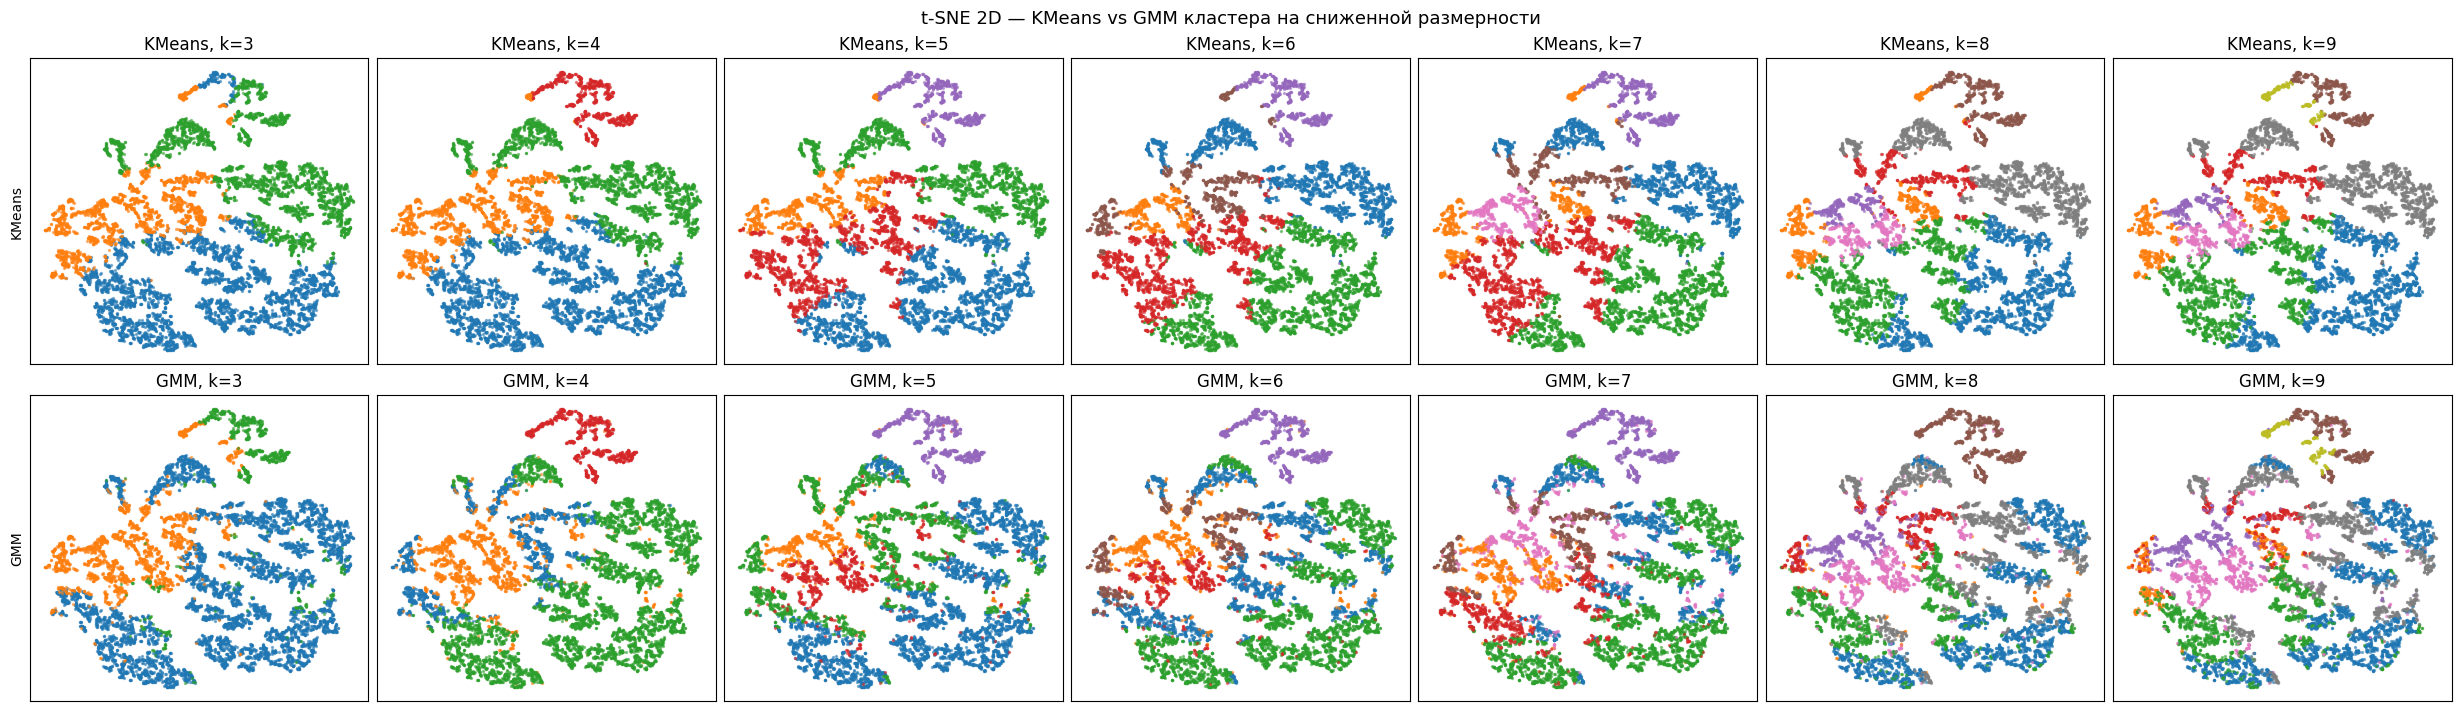

In [11]:
TSNE_SUBSAMPLE = 10_000
_rng_tsne = np.random.default_rng(RANDOM_STATE)
_tsne_idx = _rng_tsne.choice(len(X_scaled), size=min(TSNE_SUBSAMPLE, len(X_scaled)), replace=False)
X_tsne_input = X_scaled[_tsne_idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_tsne_input)

methods_tsne = ["KMeans", "GMM"]
k_list = list(k_range)
n_k = len(k_list)
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, n_k, figsize=(n_k * 3.5, 7), constrained_layout=True)

for row_idx, method in enumerate(methods_tsne):
    for col_idx, k in enumerate(k_list):
        ax = axes[row_idx, col_idx]
        labels_full = cluster_labels_dict[(method, k)]
        labels_sub = labels_full[_tsne_idx]
        for cluster_id in np.unique(labels_sub):
            mask = labels_sub == cluster_id
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c=[colors[cluster_id % 10]], s=2, alpha=0.5, label=str(cluster_id))
        ax.set_title(f"{method}, k={k}")
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(method)
plt.suptitle("t-SNE 2D — KMeans vs GMM кластера на сниженной размерности", fontsize=13)
plt.show()

## umap

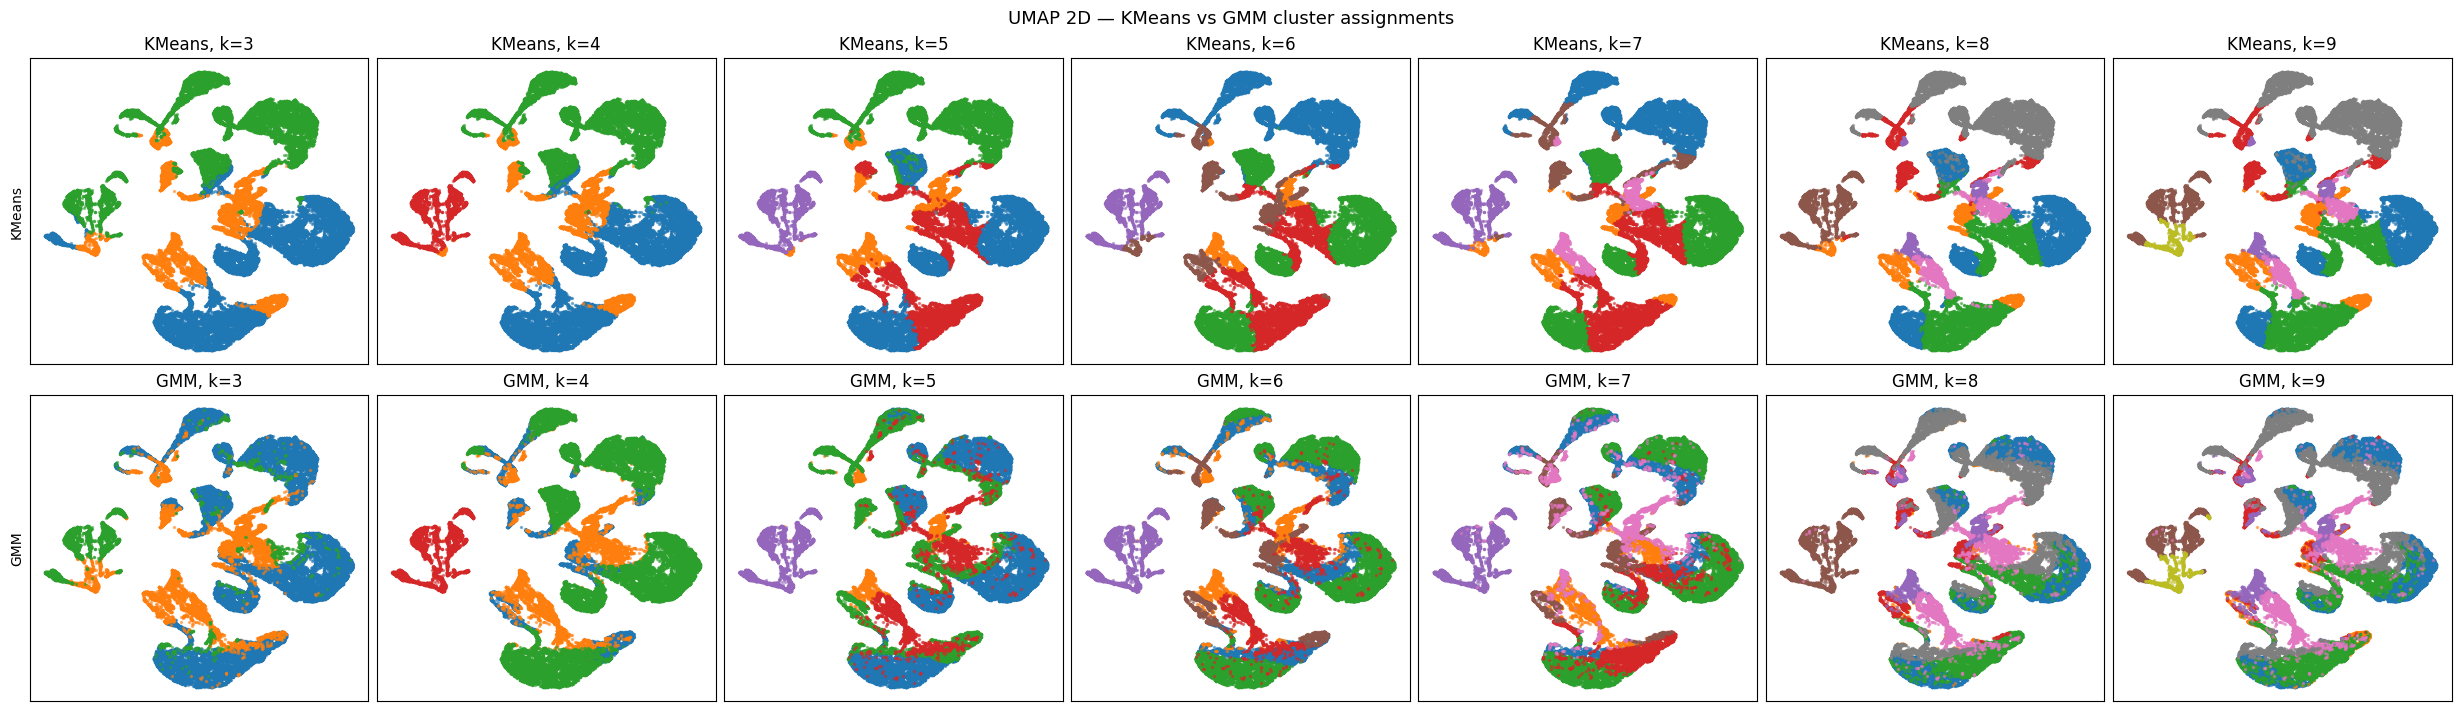

In [13]:
UMAP_SUBSAMPLE = 50_000
_rng_umap = np.random.default_rng(RANDOM_STATE)
_umap_idx = _rng_umap.choice(len(X_scaled), size=min(UMAP_SUBSAMPLE, len(X_scaled)), replace=False)
X_umap_input = X_scaled[_umap_idx]

reducer = umap.UMAP(n_components=2)
X_umap = reducer.fit_transform(X_umap_input)

methods_umap = ["KMeans", "GMM"]
k_list = list(k_range)
n_k = len(k_list)
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, n_k, figsize=(n_k * 3.5, 7), constrained_layout=True)

for row_idx, method in enumerate(methods_umap):
    for col_idx, k in enumerate(k_list):
        ax = axes[row_idx, col_idx]
        labels_full = cluster_labels_dict[(method, k)]
        labels_sub = labels_full[_umap_idx]
        for cluster_id in np.unique(labels_sub):
            mask = labels_sub == cluster_id
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                       c=[colors[cluster_id % 10]], s=2, alpha=0.5, label=str(cluster_id))
        ax.set_title(f"{method}, k={k}")
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(method)

plt.suptitle("UMAP 2D — KMeans vs GMM cluster assignments", fontsize=13)
plt.show()
